In [1]:
import sys
import os
import anndata
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import anndata
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
%load_ext autoreload
%autoreload 2
from collections import defaultdict
import torch

/home/users/siyuhe/.local/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/home/users/siyuhe/.local/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/home/users/siyuhe/.local/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
  """ Class for doing community detection using the Leiden algorithm.
/home/users/siyuhe/.local/lib/python3.12/site-packages/leidenalg/Optimiser.py:305: SyntaxWarning: invalid escape sequence '\s'
  """ Optimise the given partitions simultaneously.


# prepare data

In [3]:
count = pd.read_csv('log_normalised_counts.csv', index_col=0).transpose()
meta = pd.read_csv('cell_metadata_cols.tsv', sep='\t')


In [5]:
adata = anndata.AnnData(count)
adata.obs=meta.copy()
adata.layers["counts"] = adata.X.copy()


/hpc/mydata/siyu.he/anaconda/2023.03/x86_64/envs/scvi_v1_env/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm["X_pca"] = X_pca


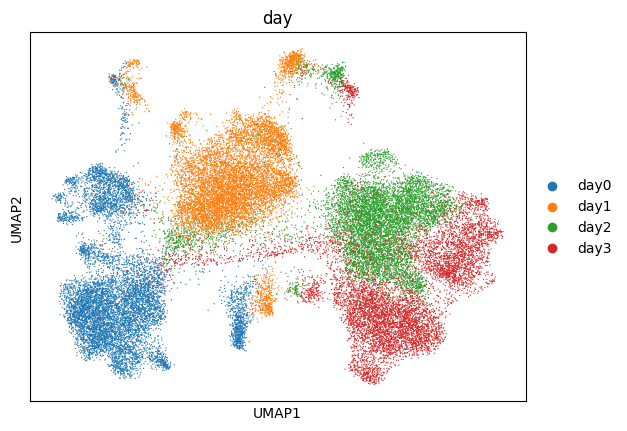

In [6]:
adata_copy = adata.copy()
sc.pp.highly_variable_genes(adata_copy)
adata_copy = adata_copy[:, adata_copy.var.highly_variable]
sc.pp.pca(adata_copy, n_comps=50)
# Compute the neighborhood graph
sc.pp.neighbors(adata_copy, n_neighbors=30, n_pcs=50)

# Run UMAP
sc.tl.umap(adata_copy)

# Plot UMAP
sc.pl.umap(adata_copy, color=['day'])  # Replace 'condition_column_name' with the relevant column name in your data
plt.show()


/tmp/ipykernel_157876/2045703018.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_copy,resolution=0.4)


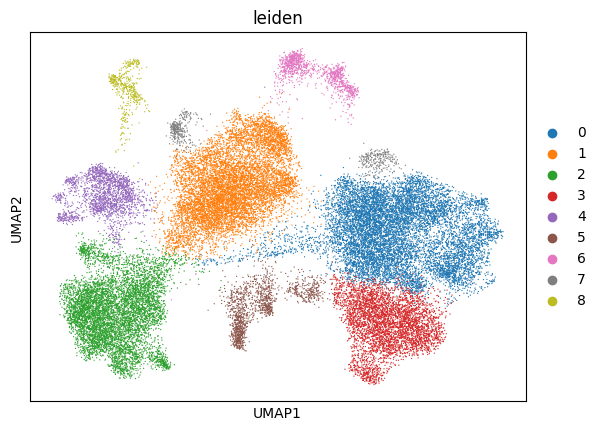

In [7]:
sc.tl.leiden(adata_copy,resolution=0.4)
sc.pl.umap(adata_copy, color=['leiden'])  # Replace 'condition_column_name' with the relevant column name in your data
plt.show()


In [8]:
adata_day0 = adata[(adata_copy.obs['leiden']=='2')&(adata_copy.obs['day']=='day0')]
adata_day1 = adata[(adata_copy.obs['leiden']=='1')&(adata_copy.obs['day']=='day1')]
adata_day2 = adata[(adata_copy.obs['leiden']=='0')&(adata_copy.obs['day']=='day2')]
adata_day3 = adata[(adata_copy.obs['leiden']=='3')&(adata_copy.obs['day']=='day3')]


new_adata = sc.concat([adata_day0,adata_day1,adata_day2, adata_day3])
new_adata

AnnData object with n_obs × n_vars = 25995 × 11231
    obs: 'assigned', 'auxDir', 'cell_filter', 'cell_name', 'compatible_fragment_ratio', 'day', 'donor', 'expected_format', 'experiment', 'frag_dist_length', 'gc_bias_correct', 'is_cell_control', 'is_cell_control_bulk', 'is_cell_control_control', 'library_types', 'libType', 'log10_total_counts', 'log10_total_counts_endogenous', 'log10_total_counts_ERCC', 'log10_total_counts_feature_control', 'log10_total_counts_MT', 'log10_total_features', 'log10_total_features_endogenous', 'log10_total_features_ERCC', 'log10_total_features_feature_control', 'log10_total_features_MT', 'mapping_type', 'mates1', 'mates2', 'n_alt_reads', 'n_total_reads', 'num_assigned_fragments', 'num_bias_bins', 'num_bootstraps', 'num_compatible_fragments', 'num_consistent_mappings', 'num_inconsistent_mappings', 'num_libraries', 'num_mapped', 'num_processed', 'num_targets', 'nvars_used', 'pct_counts_endogenous', 'pct_counts_ERCC', 'pct_counts_feature_control', 'pct_counts

In [9]:
new_adata = adata

In [17]:
import scanpy as sc
import numpy as np

# Get unique groups
groups = new_adata.obs['day'].unique()
train_adata_list = []
val_adata_list = []
test_adata_list = []

# Random sampling 3000 cells per group and splitting
for group in groups:
    group_adata = new_adata[new_adata.obs['day'] == group]
    
    # Ensure there are at least 2000 cells in the group
    if group_adata.shape[0] < 2000:
        print(f"Group {group} has less than 3000 cells. Sampling {group_adata.shape[0]} cells.")
        sampled_adata = group_adata
    else:
        sampled_indices = np.random.choice(group_adata.shape[0], 2000, replace=True)
        sampled_adata = group_adata[sampled_indices, :]

    # Shuffle the sampled data indices
    total_indices = np.arange(sampled_adata.shape[0])
    np.random.shuffle(total_indices)
    
    # Split into train, validation, and test datasets
    train_size = int(0.6 * sampled_adata.shape[0])
    val_size = int(0.1 * sampled_adata.shape[0])
    
    train_indices = total_indices[:train_size]
    val_indices = total_indices[train_size:train_size + val_size]
    test_indices = total_indices[train_size + val_size:]
    
    train_adata_list.append(sampled_adata[train_indices, :])
    val_adata_list.append(sampled_adata[val_indices, :])
    test_adata_list.append(sampled_adata[test_indices, :])

# Concatenate all subsampled data
train_adata = train_adata_list[0].concatenate(*train_adata_list[1:], batch_key="day", batch_categories=groups)
val_adata = val_adata_list[0].concatenate(*val_adata_list[1:], batch_key="day", batch_categories=groups)
test_adata = test_adata_list[0].concatenate(*test_adata_list[1:], batch_key="day", batch_categories=groups)

# Modify variable names if needed
train_adata.var_names = [i.split('_')[1] for i in train_adata.var_names]
val_adata.var_names = [i.split('_')[1] for i in val_adata.var_names]
test_adata.var_names = [i.split('_')[1] for i in test_adata.var_names]


# Identify the most highly variable genes
sc.pp.highly_variable_genes(train_adata, n_top_genes=200)
wnt_signaling = ["ADAM17",
 "AXIN1",
 "AXIN2",
 "CCND2",
 "CSNK1E",
 "CTNNB1",
 "CUL1",
 "DKK1",
 "DKK4",
 "DLL1",
 "DVL2",
 "FRAT1",
 "FZD1",
 "FZD8",
 "GNAI1",
 "HDAC11",
 "HDAC2",
 "HDAC5",
 "HEY1",
 "HEY2",
 "JAG1",
 "JAG2",
 "KAT2A",
 "LEF1",
 "MAML1",
 "MYC",
 "NCOR2",
 "NCSTN",
 "NKD1",
 "NOTCH1",
 "NOTCH4",
 "NUMB",
 "PPARD",
 "PSEN2",
 "PTCH1",
 "RBPJ",
 "SKP2",
 "TCF7",
 "TP53","WNT1","WNT5B","WNT6"]
BMP_signaling = ["AHSG","BAMBI","BMP2","BMP4","BMP6","BMP7","BMPR1A","BMPR1B","BMPR2","CER1","CHRD","CHRDL1","CTDSP1","CTDSP2","CTDSPL","FST","GREM1","GSK3B","HJV","MAP3K7","MAPK1","NOG","NUP214","PPM1A","PPP1CA","PPP1R15A","RGMA","RGMB","SKI","SMAD1","SMAD4","SMAD5","SMAD6","SMAD7","SMAD9","SMURF1","SMURF2","SOSTDC1","TAB1","TAB2","XIAP","ZFYVE16"]
others  = ['NANOG','T','GATA6']

for i in others:
    train_adata.var.highly_variable[i]=True

var_ = train_adata.var.highly_variable
train_adata = train_adata[:, var_]
val_adata = val_adata[:, var_]
test_adata = test_adata[:, var_]

# Save datasets
train_adata.write('diff_train_raw.h5ad')
val_adata.write('val_adata_raw.h5ad')
test_adata.write('test_adata_raw.h5ad')

# Print summary of each dataset
print(f"Train dataset shape: {train_adata.shape}")
print(f"Validation dataset shape: {val_adata.shape}")
print(f"Test dataset shape: {test_adata.shape}")


/tmp/ipykernel_157876/953422054.py:39: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  train_adata = train_adata_list[0].concatenate(*train_adata_list[1:], batch_key="day", batch_categories=groups)
/hpc/mydata/siyu.he/anaconda/2023.03/x86_64/envs/scvi_v1_env/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/hpc/mydata/siyu.he/anaconda/2023.03/x86_64/envs/scvi_v1_env/lib/python3.9/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/hpc/mydata/siyu.he/anaconda/2023.03/x86_64/envs/scvi_v1_env/lib/python3.9/site-packages/anndata/_core/anndat

Train dataset shape: (4800, 203)
Validation dataset shape: (800, 203)
Test dataset shape: (2400, 203)
